In [ ]:
!pip -q install wordcloud==1.9.3 imbalanced-learn==0.12.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 10.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re, os, textwrap, json, itertools
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from wordcloud import WordCloud


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving tweets.csv to tweets.csv
Saving user_reviews.csv to user_reviews.csv
Saving Twitter_Data.csv to Twitter_Data.csv


In [ ]:
# Change these filenames if your names differ
candidates = [
    "user_reviews.csv",
    "Twitter_Data.csv",
    "tweets.csv",
]

def read_any(path):
    # Try CSV then TSV then JSON lines
    try:
        return pd.read_csv(path)
    except:
        try:
            return pd.read_csv(path, sep="\t")
        except:
            return pd.read_json(path, lines=True)

df = None
for fn in candidates:
    if os.path.exists(fn):
        df = read_any(fn)
        src = fn
        break

assert df is not None, "No dataset found. Upload a CSV like user_reviews.csv or Twitter_Data.csv."

df.columns = [c.strip().replace(" ", "_") for c in df.columns]
print("Loaded:", src, "| shape:", df.shape)
df.head()


Loaded: user_reviews.csv | shape: (64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
text_col, label_col = None, None

# Common patterns
if {"Translated_Review","Sentiment"}.issubset(df.columns):
    text_col, label_col = "Translated_Review", "Sentiment"
elif {"clean_text","category"}.issubset(df.columns):
    text_col, label_col = "clean_text", "category"
elif {"text","label"}.issubset(df.columns):
    text_col, label_col = "text", "label"
elif {"tweet","label"}.issubset(df.columns):
    text_col, label_col = "tweet", "label"

# Fallback: try to guess
if text_col is None:
    for c in df.columns:
        if re.search(r"(text|tweet|review|comment|message|content|sentence)", c, re.I):
            text_col = c; break
if label_col is None:
    for c in df.columns:
        if re.search(r"(sentiment|label|category|target|polarity|class)", c, re.I):
            label_col = c; break

print("text_col =", text_col, "| label_col =", label_col)
assert text_col and label_col, "Couldn't auto-detect columns—set text_col/label_col manually."


text_col = Translated_Review | label_col = Sentiment


In [ ]:
def simple_clean(s: str) -> str:
    s = re.sub(r"http\S+|www\.\S+", " ", str(s))     # URLs
    s = re.sub(r"@[A-Za-z0-9_]+", " ", s)            # @mentions
    s = re.sub(r"#", " ", s)                         # hashtags
    s = re.sub(r"[^A-Za-z0-9\s']", " ", s)           # keep letters/numbers
    s = re.sub(r"\s+", " ", s).strip()
    return s

df = df[[text_col, label_col]].dropna()
df = df.drop_duplicates(subset=[text_col])
df = df[df[text_col].astype(str).str.strip().str.len() > 0].copy()
df["_clean"] = df[text_col].astype(str).map(simple_clean)
df.head()


,Translated_Review,Sentiment,_clean
0,I like eat delicious food. That's I'm cooking ...,Positive,I like eat delicious food That's I'm cooking f...
1,This help eating healthy exercise regular basis,Positive,This help eating healthy exercise regular basis
3,Works great especially going grocery store,Positive,Works great especially going grocery store
4,Best idea us,Positive,Best idea us
5,Best way,Positive,Best way


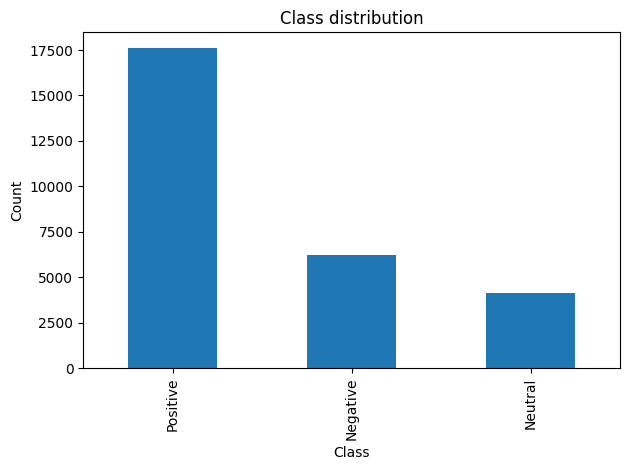

Sentiment
Positive    17593
Negative     6240
Neutral      4161
Name: count, dtype: int64


In [ ]:
vc = df[label_col].astype(str).value_counts()
plt.figure()
vc.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.tight_layout()
plt.show()
print(vc)


In [ ]:
df["_len"] = df["_clean"].str.split().apply(len)
df.groupby(label_col)["_len"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
Negative,6240.0,21.43,16.65,1.0,10.0,18.0,29.0,366.0
Neutral,4161.0,8.67,7.94,0.0,3.0,6.0,12.0,59.0
Positive,17593.0,19.59,16.86,0.0,7.0,15.0,28.0,187.0


In [ ]:
X = df["_clean"].values
y = df[label_col].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
len(X_train), len(X_test)


(22395, 5599)

LogReg — Accuracy: 0.8675 | Weighted F1: 0.8625

              precision    recall  f1-score   support

    Negative     0.8781    0.7276    0.7958      1248
     Neutral     0.8654    0.6647    0.7519       832
    Positive     0.8650    0.9650    0.9123      3519

    accuracy                         0.8675      5599
   macro avg     0.8695    0.7858    0.8200      5599
weighted avg     0.8680    0.8675    0.8625      5599



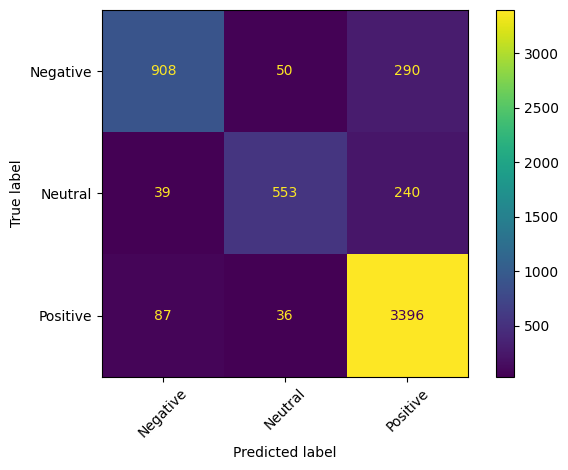

In [ ]:
logit_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
    ("clf", LogisticRegression(max_iter=300))
])

logit_pipe.fit(X_train, y_train)
pred = logit_pipe.predict(X_test)

acc = accuracy_score(y_test, pred)
f1  = f1_score(y_test, pred, average="weighted")
print(f"LogReg — Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}\n")
print(classification_report(y_test, pred, digits=4))

cm = confusion_matrix(y_test, pred, labels=sorted(np.unique(y_test)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_test)))
disp.plot(xticks_rotation=45); plt.tight_layout(); plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Train and evaluate models
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    acc = accuracy_score(y_test, p)
    f1 = f1_score(y_test, p, average="weighted")
    print(name, "Acc:", round(acc, 4), "F1(w):", round(f1, 4))


LinearSVC Acc: 0.893 F1(w): 0.8915
MultinomialNB Acc: 0.6503 F1(w): 0.5317


In [ ]:
grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [2,5],
    "tfidf__max_df": [0.9, 0.95],
}
pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, grid, scoring="f1_weighted", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
best = gs.best_estimator_
pred = best.predict(X_test)
print("Tuned Acc:", accuracy_score(y_test, pred).round(4), "F1(w):", f1_score(y_test, pred, average="weighted").round(4))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'tfidf__max_df': 0.9, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}


AttributeError: 'float' object has no attribute 'round'

In [ ]:
res = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": pred
})
errors = res[res.true != res.pred]
errors.sample(10, random_state=0)


,text,true,pred
2556,I longer log Athem using APP Call help desk mo...,Neutral,Positive
1196,Add 2FA support mobile app PS Your technical s...,Negative,Neutral
4982,Way many notifications way turn ones want Exam...,Negative,Positive
620,Spent 100 Amazon still cash back supposed 5 ca...,Negative,Neutral
4930,There's annoying bug switching back last read ...,Negative,Positive
1088,Not able save Reservation without login How ad...,Negative,Positive
4099,Good beats whatnot little frequent skips beats...,Positive,Negative
4940,I wish I knew Unfortunately Walmart ad popped ...,Negative,Positive
4213,Convenient way seek treatment cold flu Dr thor...,Negative,Neutral
396,Does says tin However curate block list I expe...,Positive,Negative


In [ ]:
import joblib, time
stamp = time.strftime("%Y%m%d_%H%M%S")
fname = f"sentiment_pipeline_{stamp}.joblib"
joblib.dump(best if 'best' in globals() else logit_pipe, fname)
fname


'sentiment_pipeline_20250902_142005.joblib'

In [ ]:
from google.colab import files
files.download(fname)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
clf = best if 'best' in globals() else logit_pipe
def predict_text(s: str):
    return clf.predict([s])[0]

predict_text("I absolutely love this app!")


'Positive'

In [ ]:
# Upload a CSV with a column named 'text' (or change text_col below)
from google.colab import files
batch = files.upload()
batch_fn = list(batch.keys())[0]
df_in = pd.read_csv(batch_fn)

# If your column isn't named 'text', change here:
in_text_col = "text"
assert in_text_col in df_in.columns, df_in.columns

df_in["predicted_sentiment"] = clf.predict(df_in[in_text_col].astype(str).fillna(""))
out_fn = "predictions.csv"
df_in.to_csv(out_fn, index=False)
files.download(out_fn)


Saving sentiment_pipeline_20250902_142005.joblib to sentiment_pipeline_20250902_142005 (1).joblib


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 0: invalid start byte